In [1]:
import numpy as np
import struct
from IPython.display import display, Markdown, Latex
from float8 import Float8
from l_mul import lmul
from math import sqrt

2
3
1
x = Float8(binary='0.0111.000', decimal=1.0, decimal_approx=1.0)
y = Float8(binary='0.0000.010', decimal=0.005, decimal_approx=0.00390625)
Normalized shift amount:  2
100
Normalized shift: 2
Normal exp: 7
BIAS: 7
carry: 0
result exp: -1
normalized mantissa result: 1.100
denormalized mantissa result: 0.011
00000011
True result:
	Float8(binary='0.0000.010', decimal=0.005, decimal_approx=0.00390625)
Calculated result:
	Float8(binary='0.0000.011', decimal=0.005859375, decimal_approx=0.005859375)



In [2]:
%reload_ext autoreload
%autoreload 2

## $Linear Mul$ Algorithm

1. Subnormal $\times$ subnormal

- Always 0

2. Normal $\times$ subnormal

- Can be 0, subnormal, or normal

3. Normal $\times$ normal

- Can be 0, subnormal, normal, or infinity


Lets implement the linear multiply algorithm in hardware for 8 bit floats with e4m3 format. The idea of the algorithm is to speed up floating point multiplication by using only addition to approximate the mantissa multiplication step.

0. If both numbers are subnormal, return 0
1. Add bits starting after sign bit and add the special offset term
2. Use the mantissa carry bit as a flag
3. Check the value of the exponent bits, if they are less than the bias, then the result is subnormal, perform step 4
4. Set exponent bits to 0, and shift the mantissa bits to the right by the difference between the exponent bits and the bias plus the value of the mantissa carry bit. Include the implicit 1 for the mantissa when bitshifting skip to step 6
5. If $\text{exponent} \ge \text{bias}$, substract $( \text{bias } \ll |\text{M}_\text{bits}| )$ from the overall result
6. If $\text{exponent} \ge 2^{|\text{E}_\text{bits}|}$, clamp result to max value
7. Prepend the sign bit to the result ($\text{S}_{x+y} = \text{S}_x \oplus \text{S}_y$)


In [3]:
def l_offset(m_bits):
    if m_bits <= 3:
        offset = m_bits
    if m_bits == 4:
        offset = 3
    if m_bits > 4:
        offset = 4
    offset = (1 << m_bits) >> offset
    # print(format(offset, f'0{m_bits}b'))
    return offset
    
l_offset(3)

1

In [59]:
format((2**(4-1)-1) << 3, '08b')

'00111000'

In [66]:
Float8.from_binint(int(0b10011010))

Float8(binary='1.0011.010', decimal=-0.078125, decimal_approx=-0.078125)

In [ ]:
def lmul_generic(x: Float8, y: Float8, e_bits: int=4, m_bits: int=3):
    sign_x, sign_y = int(x.bits[0],2), int(y.bits[0],2)
    x_float_bits, y_float_bits = int(x.bits[1:],2), int(y.bits[1:],2)

    sign = sign_x ^ sign_y
    exp_bias = (2**(e_bits-1) - 1) << m_bits
    offset = l_offset(m_bits)
    
    result = x_float_bits + y_float_bits + offset - exp_bias
    result = min(max(result, 0), 0x7F)
    result |= sign << (e_bits + m_bits) | result
    return Float8.from_binint(result)
    
    

    

In [4]:
def fp8e4m3_lmul(x: int, y: int) -> int:
    # Constants for e4m3 format
    EXPONENT_BITS = 4
    MANTISSA_BITS = 3
    BIAS = 7  # 2^(4-1) - 1
    MAX_EXP = (1 << EXPONENT_BITS) - 1  # 15
    MAX_VALUE = 0x7F  # Maximum 7-bit value (excluding sign)
    
    # Step 0: Check for subnormal inputs
    x_exp = (x >> MANTISSA_BITS) & 0xF
    y_exp = (y >> MANTISSA_BITS) & 0xF
    if x_exp == 0 and y_exp == 0:
        return 0
    
    # Step 1: Handle sign bit
    sign_x = (x >> 7) & 1
    sign_y = (y >> 7) & 1
    result_sign = sign_x ^ sign_y
    
    # Step 2: Handle mantissa addition
    x_mantissa = x & 0x7
    y_mantissa = y & 0x7
    mantissa_sum = x_mantissa + y_mantissa + 1  # Add offset term
    mantissa_carry = (mantissa_sum >> MANTISSA_BITS) & 1
    result_mantissa = mantissa_sum & 0x7  # Truncate to 3 bits
    
    # Step 3: Handle exponent addition
    exp_sum = x_exp + y_exp + mantissa_carry
    
    if exp_sum < BIAS:
        # Result is subnormal
        shift_amount = BIAS - exp_sum + mantissa_carry
        # Include implicit 1 when shifting
        implicit_bit = 1 << MANTISSA_BITS if (x_exp != 0 and y_exp != 0) else 0
        full_mantissa = implicit_bit | result_mantissa
        result_mantissa = full_mantissa >> shift_amount
        result_exp = 0
    else:
        # Normal case
        result_exp = exp_sum - BIAS
        if result_exp >= MAX_EXP:
            # Clamp to max value
            return (result_sign << 7) | MAX_VALUE
    
    # Combine results
    result = (result_exp << MANTISSA_BITS) | result_mantissa
    return (result_sign << 7) | result

def lmul_binary(x: float, y: float):
    xfloat8, yfloat8 = Float8(x), Float8(y)
    print(f"x: {xfloat8}\ny: {yfloat8}\n")
    result_int = fp8e4m3_lmul(xfloat8.binint, yfloat8.binint)
    result_binary = format(result_int, '08b')
    result = Float8(result_binary)
    
    print(f"True result:\n\t{xfloat8*yfloat8}")
    print(f"Calculated result:\n\t{result}\n")

x, y = 2, 0.008
lmul_binary(x, y)

x: Float8(binary='0.1000.000', decimal=2.0, decimal_approx=2.0)
y: Float8(binary='0.0000.100', decimal=0.008, decimal_approx=0.0078125)

True result:
	Float8(binary='0.0001.000', decimal=0.016, decimal_approx=0.015625)
Calculated result:
	Float8(binary='0.0001.101', decimal=0.025390625, decimal_approx=0.025390625)



In [5]:
def get_shift_amount(mantissa: int, m_bits: int) -> int:
    # If mantissa is 0, no shift will make it normalized
    if mantissa == 0:
        return 0
        
    # Find position of leftmost 1 by checking each bit
    # from left to right
    for i in range(m_bits):
        if mantissa & (1 << (m_bits - i)):
            # Return number of shifts needed to get leftmost 1
            # to implied position
            return i
            
    return m_bits # In case no 1 is found

print(get_shift_amount(0b010, 3)) # Prints 2
print(get_shift_amount(0b0010, 4)) # Prints 3
print(get_shift_amount(0b101, 3)) # Prints 1

2
3
1


In [6]:
x, y = 1, 0.008
lmul_binary(x, y)

x: Float8(binary='0.0111.000', decimal=1.0, decimal_approx=1.0)
y: Float8(binary='0.0000.100', decimal=0.008, decimal_approx=0.0078125)

True result:
	Float8(binary='0.0000.100', decimal=0.008, decimal_approx=0.0078125)
Calculated result:
	Float8(binary='0.0000.101', decimal=0.009765625, decimal_approx=0.009765625)



# FP8 Subnormal Multiplication Algorithm

This function implements multiplication between a normal and subnormal FP8 number using only addition operations.

## Format Details

- Uses e4m3 format (4 exponent bits, 3 mantissa bits)
- Bias = 7
- Total width = 8 bits (1 sign + 4 exponent + 3 mantissa)

## Algorithm Steps

1. **Input Processing**

   - Convert inputs to Float8 format if needed
   - Extract components from both numbers:
     - Sign bits: `s₁`, `s₂`
     - Exponents: `e₁`, `e₂`
     - Mantissas: `m₁`, `m₂`

2. **Sign Handling**

   - Result sign = `s₁ ⊕ s₂` (XOR of input signs)

3. **Identify Normal/Subnormal**

   - If either `e₁ = 0` or `e₂ = 0`, that number is subnormal
   - Store the subnormal mantissa and normal number's components separately

4. **Mantissa Processing**

   1. Add special offset to subnormal mantissa: `m_sub + L(m)`
      - Where L(m) is a precomputed offset based on mantissa width
   2. Normalize the result:
      - Find leading 1 position
      - Shift left to get implied 1
   3. Add normal number's mantissa
   4. Handle any carry from mantissa addition

5. **Exponent Calculation**

```
result_exp = normal_exp + 1 - bias - normalizing_shift + mantissa_carry
```

6. **Denormalization Check**
   If `result_exp ≤ 0`:

- Calculate denormalizing shift = |result_exp| + 1
- Set exponent to 0
- Right shift mantissa (including implied 1) by denormalizing amount

7. **Result Assembly**

- Combine sign, exponent, and mantissa:

```
result = (sign << 7) | (exp << 3) | mantissa
```

## Key Features

- Handles multiplication without actual multiplication operations
- Preserves gradual underflow behavior
- Maintains proper rounding for subnormal results
- Uses bit manipulation for efficiency

## Example

For inputs:

- Normal number: 1.0 (0b01000000)
- Subnormal number: 0.008 (0b00000100)

The algorithm normalizes the subnormal number, performs the operation using addition, and then denormalizes the result if necessary to maintain proper subnormal number handling.


In [24]:
def lmul_normsub(x:float|str|Float8, y:float|str|Float8) -> Float8:
    # Constants for e4m3 format
    E_BITS = 4
    M_BITS = 3
    PRECISION = 1 + E_BITS + M_BITS
    BIAS = 7  # 2^(4-1) - 1
    EXP_MASK = (1 << E_BITS) - 1
    MANTISSA_MASK = (1 << M_BITS) - 1
    MAX_EXP = (1 << E_BITS) - 1  # 15
    MAX_VALUE = 0x7F  # Maximum 7-bit value (excluding sign)
    
    # Convert inputs to Float8 if they are not already
    if not isinstance(x, Float8):
        xfloat8 = Float8(x)
    else:
        xfloat8 = x
    if not isinstance(y, Float8):
        yfloat8 = Float8(y)
    else:
        yfloat8 = y
        
    print(f"x = {xfloat8}")
    print(f"y = {yfloat8}")
    
    # Step 0: Check for subnormal inputs
    x_exp = (xfloat8.binint >> M_BITS) & EXP_MASK
    y_exp = (yfloat8.binint >> M_BITS) & EXP_MASK
    x_mantissa = xfloat8.binint & MANTISSA_MASK
    y_mantissa = yfloat8.binint & MANTISSA_MASK
    
    # Step 1: Handle sign bit
    sign_x = (xfloat8.binint >> 7) & 1
    sign_y = (yfloat8.binint >> 7) & 1
    result_sign = sign_x ^ sign_y
    
    if x_exp == 0 or y_exp == 0:
        # Get the subnormal number's mantissa and exp
        subnormal_mantissa = x_mantissa if x_exp == 0 else y_mantissa
        normal_mantissa = y_mantissa if x_exp == 0 else x_mantissa
        normal_exp = y_exp if x_exp == 0 else x_exp
        
        # # Strategy 1: Add the special offset term after normalizing the mantissa
        # normalizing_shift = get_shift_amount(subnormal_mantissa, M_BITS)
        # print("Normalized shift amount: ", normalizing_shift)
        # result_mantissa = (subnormal_mantissa << normalizing_shift) & MANTISSA_MASK
        # result_mantissa += l_offset(M_BITS)
        
        # Strategy 2: Add the special offset term before normalization
        result_mantissa = subnormal_mantissa + l_offset(M_BITS)
        normalizing_shift = get_shift_amount(result_mantissa, M_BITS)
        print("Normalized shift amount: ", normalizing_shift)
        result_mantissa = (result_mantissa << normalizing_shift) & MANTISSA_MASK
        result_mantissa += normal_mantissa
        mantissa_carry = (result_mantissa >> M_BITS)
        result_mantissa = result_mantissa & MANTISSA_MASK
        print(format(result_mantissa, '0b'))
        print(f"Normalized shift: {normalizing_shift}\nNormal exp: {normal_exp}\nBIAS: {BIAS}\ncarry: {mantissa_carry}")
        
        # The result's exponent is the non-zero exponent of the normal number
        result_exp = normal_exp + 1 - BIAS - normalizing_shift + mantissa_carry
        
    # If the exponent <= 0, denormalize the result
    if result_exp <= 0:
        print("result exp:", result_exp)
        print("normalized mantissa result: 1."+format(result_mantissa, f'0{M_BITS}b'))
        denormalizing_shift = abs(result_exp) + 1
        result_exp = 0
        result_mantissa = ((1 << M_BITS) + result_mantissa) >> (denormalizing_shift)
        print("denormalized mantissa result: 0."+format(result_mantissa, f'0{M_BITS}b'))    
    # Combine results
    result = (result_sign << PRECISION-1) | (result_exp << M_BITS) | result_mantissa
    print(format(result, '08b'))
    result = Float8.from_binint(result)
    print(f"True result:\n\t{xfloat8*yfloat8}")
    print(f"Calculated result:\n\t{result}\n")
    return result

# lmul_binary('0.1110.000', '0.0000.111')
# lmul_normsub('0.1110.000', '0.0000.111')
x, y = 2, 0.005
lmul_normsub(x,y)

x = Float8(binary='0.1000.000', decimal=2.0, decimal_approx=2.0)
y = Float8(binary='0.0000.010', decimal=0.005, decimal_approx=0.00390625)
Normalized shift amount:  2
100
Normalized shift: 2
Normal exp: 8
BIAS: 7
carry: 0
result exp: 0
normalized mantissa result: 1.100
denormalized mantissa result: 0.110
00000110
True result:
	Float8(binary='0.0000.101', decimal=0.01, decimal_approx=0.009765625)
Calculated result:
	Float8(binary='0.0000.110', decimal=0.01171875, decimal_approx=0.01171875)



Float8(binary='0.0000.110', decimal=0.01171875, decimal_approx=0.01171875)

In [25]:
def lmul_normsub(x:float|str|Float8, y:float|str|Float8, verbose: bool = False) -> Float8:
    # Constants for e4m3 format
    E_BITS = 4
    M_BITS = 3
    PRECISION = 1 + E_BITS + M_BITS
    BIAS = 7  # 2^(4-1) - 1
    EXP_MASK = (1 << E_BITS) - 1
    MANTISSA_MASK = (1 << M_BITS) - 1
    MAX_EXP = (1 << E_BITS) - 1  # 15
    MAX_VALUE = 0x7F  # Maximum 7-bit value (excluding sign)
    
    # Convert inputs to Float8 if they are not already
    if not isinstance(x, Float8):
        xfloat8 = Float8(x)
    else:
        xfloat8 = x
    if not isinstance(y, Float8):
        yfloat8 = Float8(y)
    else:
        yfloat8 = y
        
    if verbose:
        print(f"x = {xfloat8}")
        print(f"y = {yfloat8}")
    
    # Step 0: Check for subnormal inputs
    x_exp = (xfloat8.binint >> M_BITS) & EXP_MASK
    y_exp = (yfloat8.binint >> M_BITS) & EXP_MASK
    x_mantissa = xfloat8.binint & MANTISSA_MASK
    y_mantissa = yfloat8.binint & MANTISSA_MASK
    
    # Step 1: Handle sign bit
    sign_x = (xfloat8.binint >> 7) & 1
    sign_y = (yfloat8.binint >> 7) & 1
    result_sign = sign_x ^ sign_y
    
    if x_exp == 0 or y_exp == 0:
        # Get the subnormal number's mantissa and exp
        subnormal_mantissa = x_mantissa if x_exp == 0 else y_mantissa
        normal_mantissa = y_mantissa if x_exp == 0 else x_mantissa
        normal_exp = y_exp if x_exp == 0 else x_exp
        
        result_mantissa = subnormal_mantissa + l_offset(M_BITS)
        normalizing_shift = get_shift_amount(result_mantissa, M_BITS)
        if verbose:
            print("Normalized shift amount: ", normalizing_shift)
        result_mantissa = (result_mantissa << normalizing_shift) & MANTISSA_MASK
        result_mantissa += normal_mantissa
        mantissa_carry = (result_mantissa >> M_BITS)
        result_mantissa = result_mantissa & MANTISSA_MASK
        if verbose:
            print(format(result_mantissa, '0b'))
            print(f"Normalized shift: {normalizing_shift}\nNormal exp: {normal_exp}\nBIAS: {BIAS}\ncarry: {mantissa_carry}")
        
        # The result's exponent is the non-zero exponent of the normal number
        result_exp = normal_exp + 1 - BIAS - normalizing_shift + mantissa_carry
        
    # If the exponent <= 0, denormalize the result
    if result_exp <= 0:
        if verbose:
            print("result exp:", result_exp)
            print("normalized mantissa result: 1."+format(result_mantissa, f'0{M_BITS}b'))
        denormalizing_shift = abs(result_exp) + 1
        result_exp = 0
        result_mantissa = ((1 << M_BITS) + result_mantissa) >> (denormalizing_shift)
        if verbose:
            print("denormalized mantissa result: 0."+format(result_mantissa, f'0{M_BITS}b'))    
    
    # Combine results
    result = (result_sign << PRECISION-1) | (result_exp << M_BITS) | result_mantissa
    if verbose:
        print(format(result, '08b'))
    result = Float8.from_binint(result)
    if verbose:
        print(f"True result:\n\t{xfloat8*yfloat8}")
        print(f"Calculated result:\n\t{result}\n")
    return result

x, y = 2, 0.005
lmul_normsub(x,y, verbose=True)

x = Float8(binary='0.1000.000', decimal=2.0, decimal_approx=2.0)
y = Float8(binary='0.0000.010', decimal=0.005, decimal_approx=0.00390625)
Normalized shift amount:  2
100
Normalized shift: 2
Normal exp: 8
BIAS: 7
carry: 0
result exp: 0
normalized mantissa result: 1.100
denormalized mantissa result: 0.110
00000110
True result:
	Float8(binary='0.0000.101', decimal=0.01, decimal_approx=0.009765625)
Calculated result:
	Float8(binary='0.0000.110', decimal=0.01171875, decimal_approx=0.01171875)



Float8(binary='0.0000.110', decimal=0.01171875, decimal_approx=0.01171875)

## $Lmul$ Floating Point Multiplication Algorithm

A floating point number can be represented with a sign bit $s$, exponent bits $e$, bias $b$ and mantissa bits $m$ where the value $v$ is is calculated as:

$$
v = (-1)^{\textstyle s} \times 2^{\textstyle (e-b)} \times (1+m) \\
$$

We can use the following equation to multiply two floats together:

$$
p = (s_1 \oplus s_2) \times 2^{\textstyle (e_1+e_2-b)} \times (1+m_1+m_2+m_1 m_2)
$$

The core idea of the $Lmul$ algorithm is that we can elimate the multiplication of $m_1 \times m_2$ by approximating it with a term $L(M)$ where $M$ is the number of mantissa bits.  
The $L$ function is defined as:

$$
\begin{equation}
 L(M) =
   \left\{\begin{array}{lr}
       M, & M \le 3 \\
       3, & M = 4 \\
       4, & M \gt 4 \\
    \end{array}\right.
 \end{equation}
$$

The multiplication algorithm becomes:  
$$ (s_1 \oplus s_2) \times 2^{\textstyle (e_1+e_2-2b)} \times (1+m_1+m_2+L(M)) $$
Since the bias is counted twice, we need to add it back to get the bit representation, so the result exponent is

$$
e_{\text{unbiased}} = e_1 + e_2 - 2b \\
e_{\text{bits}} = e_{\text{unbiased}} + b \\
e_{\text{bits}} = e_1 + e_2 - b \\
$$

In practice, we can perform this algorithm by taking the $XOR$, and performing a bitwise addition on the combined exponent and mantissa parts, adding the $L(M)$ term, and subtracting the bias bitshifted to the left to align with the exponent part. This enables us to skip the normalization step since the mantissa carry is automatically added to the exponent.

However, subnormal numbers are represented differently and the algorthim needs to be slightly modified. A subnormal number is represented with exponent $e=0$ and defined as:
$$ (-1)^s \times 2^{e+1-b} \times (0+m) $$

Multiplying two subnormal numbers will always underflow to 0, but multiplying a normal $\times$ subnormal can result in 0, subnormal, or normal. The multiplication of a normal number $x$ and subnormal number $y$ with $y_e=0$ looks like:

$$
(x_s \oplus y_s) \times 2^{\textstyle (x_e+1-b)} \times (0+y_m)(1+x_m) \\
$$

The mantissa portion becomes: $(0 + y_m + y_m x_m) = (y_m + L(M))$

I am confused on how to actually implement this, help me identify any errors in the code or algorithm and explain how to fix them.


# Analysis of Lmul Algorithm for Normal × Subnormal

## Current Understanding

Your mathematical foundation is correct:

- For normal numbers: $v = (-1)^s \times 2^{(e-b)} \times (1+m)$
- For subnormal numbers: $v = (-1)^s \times 2^{(1-b)} \times (0+m)$

## Potential Issues

1. **Normalization Timing**

   - Currently, you're adding $L(M)$ before normalization
   - This might cause issues because $L(M)$ is designed to approximate m₁×m₂ in the normal case
   - When dealing with subnormal numbers, we should first normalize them to ensure proper alignment

2. **Modified Algorithm Should Be**:
   For subnormal number y:

   - Find normalizing_shift $k$ where $(y_m$ `<<` $k)$ has leading $1$
   - Normalized mantissa = $y_m$ `<<` $k$
   - Adjusted exponent = $(1-b) - k$
   - After normalization: result*mantissa = $\text{normalized}*{\textstyle y*m} + L(M) + x_m$, $\text{result}*{\text{exp}} = x*e + \text{adjusted}*{\textstyle y\_{\text{exp}}}$

3. **Offset Term Placement**
   The $L(M)$ term should be added after normalization because:

- $L(M)$ approximates the product term in $(1+m_1)(1+m_2)$
- For this to work, both numbers should be in normalized form

4. **Exponent Handling**
   Your current equation:  
   result_exp = normal_exp + 1 - BIAS - normalizing_shift + mantissa_carry

Should account for:

- The normalization shift
- The fact that subnormal exponent starts at 1-bias
- Any carry from mantissa addition

5. **Edge Cases**

- Need to handle when result needs to be denormalized
- Need to check for underflow/overflow
- Need to handle zero inputs

## Suggested Modifications

```python
# Pseudocode for corrected algorithm
def lmul_normsub(x, y):
 # Assuming y is subnormal

 # 1. Normalize subnormal number first
 norm_shift = get_shift_amount(y_mantissa, M_BITS)
 norm_mantissa = (y_mantissa << norm_shift)

 # 2. Adjusted exponent for normalized subnormal
 y_adj_exp = (1 - BIAS) - norm_shift

 # 3. Now perform regular Lmul algorithm with normalized values
 result_mantissa = norm_mantissa + l_offset(M_BITS) + x_mantissa
 result_exp = x_exp + y_adj_exp + mantissa_carry

 # 4. Check if result needs denormalization
 if result_exp <= 0:
     # Denormalize result
```


In [32]:
def lmul_sub_modified(x:float|str|Float8, y:float|str|Float8, verbose: bool = False) -> Float8:
    # Constants for e4m3 format
    E_BITS = 4
    M_BITS = 3
    PRECISION = 1 + E_BITS + M_BITS
    BIAS = 7  # 2^(4-1) - 1
    EXP_MASK = (1 << E_BITS) - 1
    MANTISSA_MASK = (1 << M_BITS) - 1
    MAX_EXP = (1 << E_BITS) - 1  # 15
    MAX_VALUE = 0x7F  # Maximum 7-bit value (excluding sign)
    
    # Convert inputs to Float8 if they are not already
    if not isinstance(x, Float8):
        xfloat8 = Float8(x)
    else:
        xfloat8 = x
    if not isinstance(y, Float8):
        yfloat8 = Float8(y)
    else:
        yfloat8 = y
        
    if verbose:
        print(f"x = {xfloat8}")
        print(f"y = {yfloat8}")
    
    # Step 0: Check for subnormal inputs
    x_exp = (xfloat8.binint >> M_BITS) & EXP_MASK
    y_exp = (yfloat8.binint >> M_BITS) & EXP_MASK
    x_mantissa = xfloat8.binint & MANTISSA_MASK
    y_mantissa = yfloat8.binint & MANTISSA_MASK
    
    # Step 1: Handle sign bit
    sign_x = (xfloat8.binint >> 7) & 1
    sign_y = (yfloat8.binint >> 7) & 1
    result_sign = sign_x ^ sign_y
    
    if x_exp == 0 or y_exp == 0:
        # 0. Identify subnormal and normal numbers
        subnormal_mantissa = x_mantissa if x_exp == 0 else y_mantissa
        normal_mantissa = y_mantissa if x_exp == 0 else x_mantissa
        normal_exp = y_exp if x_exp == 0 else x_exp
        
        # First normalize the subnormal mantissa
        subnormal_mantissa += l_offset(M_BITS)
        norm_shift = get_shift_amount(subnormal_mantissa, M_BITS)
        normalized_mantissa = (subnormal_mantissa << norm_shift) & MANTISSA_MASK
        
        # Calculate the result mantissa from normalized values
        result_mantissa = normal_mantissa + normalized_mantissa #+ l_offset(M_BITS)
        
        # Check if the mantissa addition step resulted in an overflow
        if result_mantissa > MANTISSA_MASK:
            result_mantissa &= MANTISSA_MASK
            result_mantissa >>= 1
            norm_shift += 1
        
         # 2. Adjusted exponent for normalized subnormal
        subnorm_adj_exp = (1 - BIAS) - norm_shift
        
        # 3. Calculate the result exponent
        result_exp = normal_exp + subnorm_adj_exp
        
        # Check for 0 exponent after addition, which means the result is denormalized
        if result_exp <= 0:
            # Denormalize result
            denorm_shift = 1 - result_exp
            result_mantissa = ((1<<M_BITS)+result_mantissa) >> denorm_shift
            result_exp = 0

    # Combine results
    result = (result_sign << PRECISION-1) | (result_exp << M_BITS) | result_mantissa
    if verbose:
        print(format(result, '08b'))
    result = Float8.from_binint(result)
    if verbose:
        print(f"True result:\n\t{xfloat8*yfloat8}")
        print(f"Calculated result:\n\t{result}\n")
    return result

x, y = 2, 0.005
lmul_sub_modified(x,y, verbose=True)

x = Float8(binary='0.1000.000', decimal=2.0, decimal_approx=2.0)
y = Float8(binary='0.0000.010', decimal=0.005, decimal_approx=0.00390625)
00000110
True result:
	Float8(binary='0.0000.101', decimal=0.01, decimal_approx=0.009765625)
Calculated result:
	Float8(binary='0.0000.110', decimal=0.01171875, decimal_approx=0.01171875)



Float8(binary='0.0000.110', decimal=0.01171875, decimal_approx=0.01171875)

In [30]:
MANTISSA_MASK = 0b111
x = 0b101
y = 0b100
l = 0b001
result_mantissa = x + y + l
print(format(result_mantissa, '0b'))
result_mantissa &= MANTISSA_MASK
result_mantissa >>= 1
print(format(result_mantissa, '03b'))

1010
001


In [40]:
import itertools
from typing import Callable
import pandas as pd

def generate_subnormals(m_bits):
    # Generate subnormal numbers
    subnormals = []
    for i in range(1, 2**m_bits):
        subnormals.extend([s+'.0000.' + format(i, f'0{m_bits}b') for s in ['0','1']])
    return subnormals

def generate_normals(e_bits, m_bits):
    # Generate normal numbers
    normals = []
    for e in range(1, 2**e_bits-1):
        for m in range(0, 2**m_bits):
            normals.extend([s+'.'+format(e, f'0{e_bits}b')+'.'+format(m, f'0{m_bits}b') for s in ['0','1']])
    return normals

def generate_test_cases(e_bits, m_bits):
    # Generate all possible test cases
    subnormals = generate_subnormals(m_bits)
    normals = generate_normals(e_bits, m_bits)
    test_cases = list(itertools.product(subnormals, normals))
    return test_cases

def test_all_normal_subnormal(e_bits: int, m_bits: int, func: Callable[[Float8,Float8],Float8]):
    # Test all possible combinations of subnormal and normal numbers
    test_cases = generate_test_cases(e_bits, m_bits)
    results = []
    for x, y in test_cases:
        # try:
            xfloat8, yfloat8 = Float8(x), Float8(y)
            true_result = xfloat8 * yfloat8
            calculated_result = func(x, y)
            results.append({
                "x_binary": x,
                "y_binary": y,
                "x_decimal": xfloat8.decimal,
                "y_decimal": yfloat8.decimal,
                "true_result_binary": true_result.binary,
                "true_result_decimal": true_result.decimal,
                "true_result_decimal_approx": true_result.decimal_approx,
                "calculated_result_decimal": calculated_result.decimal,
                "calculated_result_binary": calculated_result.binary,
                "error": calculated_result.decimal_approx - true_result.decimal_approx
            })
        # except Exception as e:
        #     print(f"Error occurred for x={x} and y={y}: {e}")
    df = pd.DataFrame(results)
    return df

df = test_all_normal_subnormal(4, 3, lmul_normsub)
df.head()

,x_binary,y_binary,x_decimal,y_decimal,true_result_binary,true_result_decimal,true_result_decimal_approx,calculated_result_decimal,calculated_result_binary,error
0,0.0000.001,0.0001.000,0.001953,0.015625,0.0000.000,0.000031,0.0,0.0,0.0000.000,0.0
1,0.0000.001,1.0001.000,0.001953,-0.015625,1.0000.000,-0.000031,0.0,0.0,1.0000.000,0.0
2,0.0000.001,0.0001.001,0.001953,0.017578,0.0000.000,0.000034,0.0,0.0,0.0000.000,0.0
3,0.0000.001,1.0001.001,0.001953,-0.017578,1.0000.000,-0.000034,0.0,0.0,1.0000.000,0.0
4,0.0000.001,0.0001.010,0.001953,0.019531,0.0000.000,0.000038,0.0,0.0,0.0000.000,0.0


<Axes: >

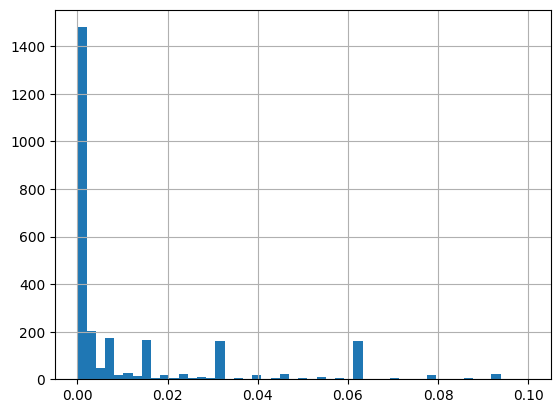

In [51]:
df['error'].abs().hist(bins=np.linspace(0,0.1,50))

<Axes: >

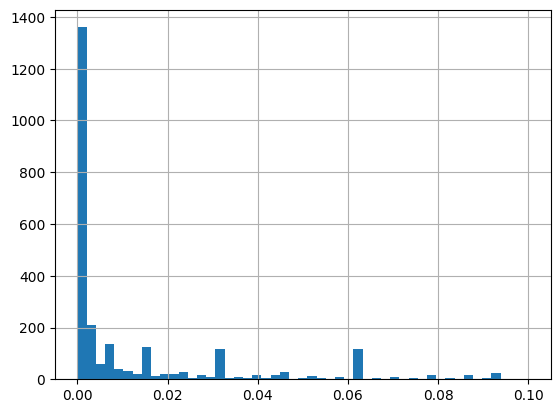

In [50]:
df_lmul_mod = test_all_normal_subnormal(4, 3, lmul_sub_modified)
df_lmul_mod['error'].abs().hist(bins=np.linspace(0,0.1,50))

<Axes: >

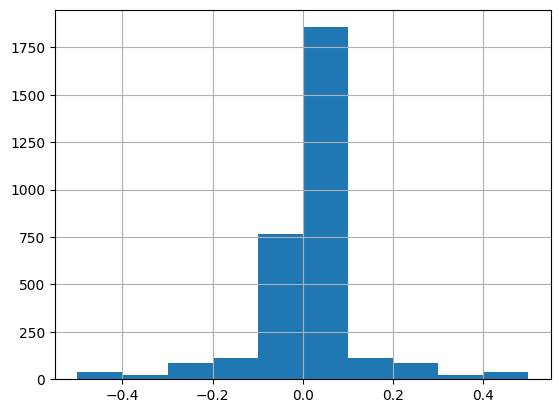

In [ ]:
lmul_result = 5
true_result = 6
true_result_approx = 5.5

true_result_error = true_result - true_result_approx
abs_error = lmul_result - true_result
lmul_error = 

1. Normalize subnormal

- shift amount = index of MSB in mantissa
- shift mantissa left
- subtract shift amount from exponent


In [71]:
lmul_normsub('0.1111.000', '0.0000.001')

x = Float8(binary='0.1111.000', decimal=256.0, decimal_approx=256.0)
y = Float8(binary='0.0000.001', decimal=0.001953125, decimal_approx=0.001953125)
Normalized shift amount:  3
True result:
	Float8(binary='0.0110.000', decimal=0.5, decimal_approx=0.5)
Calculated result:
	Float8(binary='0.0110.001', decimal=0.5625, decimal_approx=0.5625)



## Float8 Specification


OFP8 representation consists of sign, exponent, and mantissa fields. In this specification we
use the term mantissa to refer to the trailing significand bits. Two encodings are defined - E4M3
and E5M2, where the name explicitly states the number of bits in the exponent (E) and mantissa
(M) fields. Encodings consist of:

- 1 sign bit: the most significant bit
- e-bit biased exponent: 4 bits for E4M3, 5 bits for E5M2
- m mantissa (trailing significand) bits: 3 bits for E4M3, 2 bits for E5M2

The value, v, of a normal OFP8 number is
$$ v = (−1)^S × 2^{E−bias} × (1 + 2^{−m} × M) $$
The value, v, of a subnormal OFP8 number (subnormals have E = 0 and M > 0) is
$$ v = (−1)^S × 2^{1−bias} × (0 + 2^{−m} × M) $$

Exponent parameters and min/max values for both OFP8 formats are specified in Table 1.
The E5M2 format represents infinities and NaNs. Interpretation of the three mantissa values for
NaNs is not defined. The E4M3 format does not represent infinities and uses only two bit
patterns for NaN (a single mantissa-exponent bit pattern but allowing both values of the sign bit)
in order to increase emax to 8 and thus to increase the dynamic range by one binade. Various
values for OFP8 formats are detailed in Table 2.

### Table 1: OFP8 exponent parameters

| Parameter       | E4M3 | E5M2 |
| --------------- | ---- | ---- |
| Exponent bias   | 7    | 15   |
| emax (unbiased) | 8    | 15   |
| emin (unbiased) | -6   | -14  |

### Table 2: OFP8 value encoding details

| Parameter            | E4M3                        | E5M2                        |
| -------------------- | --------------------------- | --------------------------- |
| Infinities           | N/A                         | S.11111.00₂                 |
| NaN                  | S.1111.111₂                 | S.11111.{01, 10, 11}₂       |
| Zeros                | S.0000.000₂                 | S.00000.00₂                 |
| Max normal number    | S.1111.110₂ = ±448          | S.11110.11₂ = ±57,344       |
| Min normal number    | S.0001.000₂ = ±2⁻⁶          | S.00001.00₂ = ±2⁻¹⁴         |
| Max subnormal number | S.0000.111₂ = ±0.875 \* 2⁻⁶ | S.00000.11₂ = ±0.75 \* 2⁻¹⁴ |
| Min subnormal number | S.0000.001₂ = ±2⁻⁹          | S.00000.01₂ = ±2⁻¹⁶         |
| Dynamic range        | 18 binades                  | 32 binades                  |


The value, v, of a normal OFP8 number is
$$ v = (−1)^S × 2^{E−bias} × (1 + 2^{−m} × M) $$
The value, v, of a subnormal OFP8 number (subnormals have E = 0 and M > 0) is
$$ v = (−1)^S × 2^{1−bias} × (0 + 2^{−m} × M) $$


#### Normal vs subnormal multiplication of floating point (8-bit)

Exponent addition
$E_x, E_y$ are unbiased exponents that represent the true exponent when performing operations  
$E_{X \text{bits}}, E_{Y \text{bits}}$ are the exponents stored in the bit representation  
To find the bit representation of the exponent after addition, we use the following formula (normal numbers):

$$
E_x = E_{X \text{bits}} + bias \\
E_y = E_{Y \text{bits}} + bias \\

E_{x+y} = E_x + E_y = E_{X \text{bits}} + E_{Y \text{bits}} + 2*bias \\
\text{Because the bias is added twice, we need to subtract it once to get the correct exponent:} \\
E_{X+Y\text{bits}} = E_{x+y} - bias = E_{X \text{bits}} + E_{Y \text{bits}} - bias
$$

For subnormal numbers:

$$

E_{X \text{bits}} = 0 \
E_{Y \text{bits}} = 0 \
E_x = 1 - bias \
E_y = 1 - bias \
E


$$

mul(x, y) = (-1)^S × 2^{E_x + E_y - bias} × (1 + 2^{-m} × M_x) × (1 + 2^{-m} × M_y)

$$
$$


##

---


---

### Float 8 Range of Values


In [49]:
# E4M3 max/min values (positive only)

# 0_1111_110
E4M3_MAX_NORMAL = 448.0  # 1.1110₂ × 2⁸ = (1 + 14/16) × 2⁸
# 0_0001_000
E4M3_MIN_NORMAL = 2**-6  # 1.000₂ × 2⁻⁶ = 1 × 2⁻⁶
# 0_0000_111
E4M3_MAX_SUBNORMAL = 0.875 * 2**-6  # 0.111₂ × 2⁻⁶ = 7/8 × 2⁻⁶  
# 0_0000_001
E4M3_MIN_SUBNORMAL = 2**-9  # 0.001₂ × 2⁻⁶ = 1/8 × 2⁻⁶ = 2⁻⁹

#print all values
print("E4M3 max normal value: ", E4M3_MAX_NORMAL)
print("E4M3 min normal value: ", E4M3_MIN_NORMAL)
print("E4M3 max subnormal value: ", E4M3_MAX_SUBNORMAL)
print("E4M3 min subnormal value: ", E4M3_MIN_SUBNORMAL)

E4M3 max normal value:  448.0
E4M3 min normal value:  0.015625
E4M3 max subnormal value:  0.013671875
E4M3 min subnormal value:  0.001953125


In [5]:
from typing import Literal

FLOAT_SPECS = {
    'fp8': {'exp_bits': 4, 'man_bits': 3},
    'e4m3': {'exp_bits': 4, 'man_bits': 3},
    'e5m2': {'exp_bits': 5, 'man_bits': 2},
    'bfloat16': {'exp_bits': 8, 'man_bits': 7},
    'float16': {'exp_bits': 5, 'man_bits': 10},
    'float32': {'exp_bits': 8, 'man_bits': 23},
    'float64': {'exp_bits': 11, 'man_bits': 52},
}

def binary(n: int, length: int = 4) -> str:
    return format(n, f"0{length}b")

def calculate_offset(exponent_bits, mantissa_bits, output: Literal['b','d','x']='b'):
    if mantissa_bits <= 3:
        offset = mantissa_bits
    elif mantissa_bits == 4:
        offset = 3
    else:
        offset = 4

    offset = (1 << (mantissa_bits-offset))
    print(f"Mantissa offset:\n\t0|{exponent_bits*'0'}|{binary(offset, mantissa_bits)}\n")
    
    bias = 2 ** (exponent_bits - 1) - 1
    print(f"Exponent bias:\n\t0|{binary(bias, exponent_bits)}|{mantissa_bits*'0'}\n")
    bias = (bias << mantissa_bits)

    result = bias - offset
    total_bits = exponent_bits + mantissa_bits + 1
    print(f"Total Offset:\n\t{binary(result, total_bits)}")
    # print(f"\n\t{format(result, f'0{total_bits if output!='d' else ''}{output}')}")
    # return result
    return binary(result, total_bits)

calculate_offset(4,3, 'x')

Mantissa offset:
	0|0000|001

Exponent bias:
	0|0111|000

Total Offset:
	00110111


'00110111'

In [2]:
BIAS = 7
EXP_BITS = 4
M_BITS = 3

min_exp = 1 - BIAS
max_exp = 2**(EXP_BITS) - 1 - BIAS

min_subnorm_mant = 2**(-M_BITS)
max_subnorm_mant = sum([2**(-i-1) for i in range(M_BITS)])

min_norm_mant = 1
max_norm_mant = 1 + max_subnorm_mant

def calc_float(exponent, mantissa):
    return mantissa * 2**exponent

min_normal = calc_float(min_exp, min_norm_mant)
max_normal = calc_float(max_exp, max_norm_mant)
min_subnormal = calc_float(min_exp, min_subnorm_mant)
max_subnormal = calc_float(min_exp, max_subnorm_mant)

# Print the results
print(f"{1+EXP_BITS+M_BITS} bit float: "+'0_'+'0'*EXP_BITS+'_'+'0'*M_BITS+f' (bias={BIAS})')
print(f"Min Normal: {min_normal}")
print(f"Max Normal: {max_normal}")
print(f"Min Subnormal: {min_subnormal}")
print(f"Max Subnormal: {max_subnormal}")

8 bit float: 0_0000_000 (bias=7)
Min Normal: 0.015625
Max Normal: 480.0
Min Subnormal: 0.001953125
Max Subnormal: 0.013671875


---

### Testing Lmul Algorithm


In [1]:
from l_mul import binary_fp8e4m3_lmul
from float8 import Float8
from l_mul import lmul

In [3]:
def test_lmul(x: float, y: float):
    return lmul(Float8(x), Float8(y))

In [4]:
test_lmul(0.001, 2)

{'binary_result': Float8(binary='00001001', decimal=0.017578125, decimal_approx=0.017578125),
 'true_result': Float8(binary='0.0000.001', decimal=0.002, decimal_approx=0.001953125),
 'error': 0.015578125}

In [37]:
x, y = Float8('0.0000.101'), Float8('0.0101.011')
# x, y = Float8('0.0010.100'), Float8('0.0011.100')
# x, y = Float8('0.0010.111'), Float8('0.0010.111')
# x, y = Float8('0.0100.001'), Float8('0.0001.011')
print(x, y)
print("X*Y=", x*y)
print("LMUL(X,Y)=", lmul(x, y))

00000101 00101011
X*Y= 0.0000.001
LMUL(X,Y)= {'binary_result': Float8(binary='00000000', decimal=0.0, decimal_approx=0.0), 'true_result': Float8(binary='0.0000.001', decimal=0.00335693359375, decimal_approx=0.001953125), 'error': 0.00335693359375}


In [49]:
format(0b101011+0b101+1, '08b')

'00110001'

In [45]:
Float8(sqrt(0.013671875))*Float8(sqrt(0.013671875))

Float8(binary='0.0000.111', decimal=0.013671875, decimal_approx=0.013671875)

In [38]:
Float8('00000111')

Float8(binary='00000111', decimal=0.013671875, decimal_approx=0.013671875)

In [23]:
from math import sqrt


Float8(sqrt(0.001953125))

Float8(binary='0.0010.011', decimal=0.04419417382415922, decimal_approx=0.04296875)

In [55]:
Float8(0.75)*Float8(0.03)

Float8(binary='0.0001.011', decimal=0.0225, decimal_approx=0.021484375)

In [42]:
Float8('0.0001.010')

Float8(binary='00001010', decimal=0.01953125, decimal_approx=0.01953125)

In [68]:
Float8('0.1010.101') * Float8('0.0101.010')

Float8(binary='0.1001.000', decimal=4.0625, decimal_approx=4.0)

In [69]:
lmul(Float8('0.1010.100'), Float8('0.0011.100'))

{'binary_result': Float8(binary='00111001', decimal=1.125, decimal_approx=1.125),
 'true_result': Float8(binary='0.0111.001', decimal=1.125, decimal_approx=1.125),
 'error': 0.0}

In [67]:
min_subnormal

0.001953125

In [63]:
Float8('0.0010.011')*Float8('0.0010.011')

Float8(binary='0.0000.000', decimal=0.0018463134765625, decimal_approx=0.0)

In [66]:
Float8('0.0010.011')

Float8(binary='00010011', decimal=0.04296875, decimal_approx=0.04296875)

In [62]:
lmul(Float8('0.0010.011'), Float8('0.0010.011'))

ValueError: Binary string must be exactly 8 bits of 0's and 1's

In [60]:
lmul(Float8('0.0100.001'), Float8('0.0011.011'))

{'binary_result': Float8(binary='00000101', decimal=0.009765625, decimal_approx=0.009765625),
 'true_result': Float8(binary='0.0000.110', decimal=0.0120849609375, decimal_approx=0.01171875),
 'error': 0.0023193359375}

In [25]:
Float8('0.0010.011')

Float8(binary='00010011', decimal=0.04296875, decimal_approx=0.04296875)

In [175]:
# Decimal 6.0 -> fp8_e4m3 = 0|1001|100
display_float8_conversion('00110000')

<IPython.core.display.Latex object>

0.5

In [176]:
display_float8_conversion('0000000')

<IPython.core.display.Latex object>

0

In [77]:
# Decimal 1.5 -> fp8_e4m3 = 0|0111|100
display_float8_conversion('00111100')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [54]:
display_float8_conversion('01010001')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

0 | 1001100 # 6.0  
0 | 0111100 # 1.5  
 |---------------  
0 |10001000


In [163]:
bin((0b10001000>>1) - 0x3F)

'0b101'

In [161]:
0b10001

17

In [159]:
0x3F

63

In [143]:
int('11111111',2)-(int('1001100', 2)+int('0111100',2)-1)

120

In [123]:
display_float8_conversion('01010001')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [78]:
bin(0b1001100+0b0111100)

'0b10001000'

In [46]:
display_float8_conversion('00001001')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [170]:
def float8_lmul(x, y):
    # Step 1: Extract sign, exponent, and mantissa bits from inputs
    sign_x, exponent_x, mantissa_x = (x >> 7) & 1, (x >> 3) & 0xF, x & 0x7
    sign_y, exponent_y, mantissa_y = (y >> 7) & 1, (y >> 3) & 0xF, y & 0x7

    # Step 2: Calculate the output sign as XOR of input signs
    result_sign = sign_x ^ sign_y

    # Step 3: Add exponents and subtract the bias (7 for e4m3 float8)
    result_exponent = exponent_x + exponent_y - 7

    # Step 4: Perform the L-Mul mantissa calculation as a single addition
    result_mantissa = mantissa_x + mantissa_y + (1 << (3 ))  # Using l(3) = 3

    # Step 5: Normalize mantissa if overflow occurs and adjust exponent accordingly
    if result_mantissa >= 8:
        result_exponent += 1
        result_mantissa -= 8

    # Handle potential overflow in the exponent
    if result_exponent > 15:
        result_exponent = 15  # Saturate exponent for max float8 representation

    # Step 6: Combine sign, exponent, and mantissa into a final result
    return (result_sign << 7) | ((result_exponent & 0xF) << 3) | (result_mantissa & 0x7)

# Input: x = 0b1001100 (6.0), y = 0b0111100 (1.5)
x, y = 0b01001100, 0b00111100
result = float8_lmul(x, y)
print(f"Result (binary): {result:08b}")

Result (binary): 01010000


In [183]:
def float8_lmul(x, y):
    # Step 1: Extract sign bits
    sign_x, sign_y = (x >> 7) & 1, (y >> 7) & 1

    # Step 2: XOR the signs for the resulting sign bit
    result_sign = sign_x ^ sign_y

    # Step 3: Perform single addition on the entire exponent-mantissa combination, then subtract offset
    combined_value = (x & 0x7F) + (y & 0x7F) - 0x3F  # Offset is 0x3F for e4m3 format
    print(bin(combined_value))

    # Step 4: Handle overflow by saturating if combined_value exceeds the representable range
    if combined_value > 0x7F:
        combined_value = 0x7F  # Saturate to max representable value for float8

    # Step 5: Combine sign with result and return the final float8 result
    return (result_sign << 7) | (combined_value & 0x7F)

# Input: x = 0b1001100 (6.0), y = 0b0111100 (1.5)
x, y = 0b01001100, 0b00111100
result = float8_lmul(x, y)
print(f"Result (binary): {result:08b}")
display_float8_conversion(f"{result:08b}")

0b1001001
Result (binary): 01001001


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [124]:
def float8_lmul(x, y):
    # Extract components
    sign_x = (x >> 7) & 1
    sign_y = (y >> 7) & 1
    exp_x = (x >> 3) & 0xF 
    exp_y = (y >> 3) & 0xF
    mant_x = x & 0x7
    mant_y = y & 0x7
    
    # Print extracted components
    print(f"sign_x: {sign_x}")
    print(f"sign_y: {sign_y}")
    print(f"exp_x: {exp_x:0b}")
    print(f"exp_y: {exp_y:0b}")
    print(f"mant_x: {mant_x:0b}")
    print(f"mant_y: {mant_y:0b}")
    # Step 1: XOR signs
    result_sign = sign_x ^ sign_y
    
    # Step 2: Add exponents (subtract bias once since we're adding)
    # For e4m3 format, bias is 7
    result_exp = exp_x + exp_y - 7
    
    # Step 3: Add mantissas and fixed offset 2^(-l(m))
    # For 3-bit mantissa, l(m)=3, so offset is 0.125 in normalized form
    # In fixed point, this means adding 1 to mantissa bits
    result_mant = mant_x + mant_y + 1
    
    # Handle mantissa overflow
    if result_mant >= 8:
        result_mant -= 8
        result_exp += 1
        
    # Handle exponent bounds
    result_exp = min(max(result_exp, 0), 15)
    
    # Combine results
    return (result_sign << 7) | (result_exp << 3) | result_mant

# Input: x = 0b1001100 (6.0), y = 0b0111100 (1.5)
x, y = 0b01001100, 0b00111100
result = float8_lmul(x, y)
print(f"Result (binary): {result:08b}")
display_float8_conversion(f"{result:08b}")


sign_x: 0
sign_y: 0
exp_x: 1001
exp_y: 111
mant_x: 100
mant_y: 100
Result (binary): 01010001


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [237]:
def float8_lmul(x, y):
    # Step 1: Handle sign bit 
    sign_x = (x >> 7) & 1
    sign_y = (y >> 7) & 1
    result_sign = sign_x ^ sign_y
    
    # Step 2: Add the remaining 7 bits (exponent + mantissa)
    remaining_bits_x = x & 0x7F
    remaining_bits_y = y & 0x7F
    
    # For e4m3 format:
    # - l(m) = 3 since m = 3
    # - 2^(-l(m)) = 2^(-3) = 0.125 in normalized form
    # - In our fixed point representation, this is adding 1 to mantissa bits
    # - Bias adjustment needs -7 since we're adding exponents
    result = remaining_bits_x + remaining_bits_y + (1 << 0) - (7 << 3)
    # display_float8_conversion(binary(result, 8))
    
    # Clamp to valid 7-bit range
    result = min(max(result, 0), 0x7F)
    
    # Combine sign and result
    return (result_sign << 7) | result

# Input: x = 0b1001100 (6.0), y = 0b0111100 (1.5)
x, y = 0b00111000, 0b01000000
result = float8_lmul(x, y)
print(f"Result (binary): {result:08b}")
display_float8_conversion(f"{result:08b}")


Result (binary): 01000001


<IPython.core.display.Latex object>

2.25

In [232]:
display_float8_conversion('01000000')

<IPython.core.display.Latex object>

2.0

In [233]:
display_float8_conversion('00111000')

<IPython.core.display.Latex object>

1.0

---

### Test accuracy


In [248]:
def float8_lmul(x, y):
    # Step 1: Handle sign bit 
    sign_x = (x >> 7) & 1
    sign_y = (y >> 7) & 1
    result_sign = sign_x ^ sign_y
    
    # Extract exponents and mantissas
    exp_x = (x >> 3) & 0xF
    exp_y = (y >> 3) & 0xF
    mant_x = x & 0x7
    mant_y = y & 0x7
    
    # Handle subnormal numbers
    # For subnormals (exp=0), there is no implicit leading 1
    if exp_x == 0:
        exp_x = 1  # Use emin
        mant_x = mant_x  # No implicit 1
    else:
        mant_x = mant_x | 0x8  # Add implicit leading 1 (0b1000)
        
    if exp_y == 0:
        exp_y = 1  # Use emin
        mant_y = mant_y  # No implicit 1
    else:
        mant_y = mant_y | 0x8  # Add implicit leading 1
    
    # Combine exponent and mantissa
    remaining_bits_x = (exp_x << 3) | (mant_x & 0x7)
    remaining_bits_y = (exp_y << 3) | (mant_y & 0x7)
    
    # Add with offset adjustment
    # - l(m) = 3 since m = 3
    # - 2^(-l(m)) = 2^(-3) = 0.125 in normalized form
    # - Bias adjustment needs -7 since we're adding exponents
    result = remaining_bits_x + remaining_bits_y + (1 << 0) - (7 << 3)
    
    # Clamp to valid 7-bit range
    result = min(max(result, 0), 0x7F)
    
    # Special case: if result exponent would be 0, we need to handle subnormal output
    if (result >> 3) == 0:
        # Keep mantissa as is for subnormal output
        result = result & 0x7
    
    # Combine sign and result
    return (result_sign << 7) | result

def test_subnormal_cases():
    test_cases = [
        (0b00000100, 0b00000100),  # subnormal * subnormal
        (0b00000100, 0b00001100),  # subnormal * normal
        (0b00000111, 0b00000111),  # max subnormal * max subnormal
        (0b00001000, 0b00000001),  # min normal * min subnormal
    ]
    
    results = []
    for x_bin, y_bin in test_cases:
        x_dec = fp8_e4m3_to_decimal(x_bin)
        y_dec = fp8_e4m3_to_decimal(y_bin)
        result_bin = float8_lmul(x_bin, y_bin)
        result_dec = fp8_e4m3_to_decimal(result_bin)
        expected_dec = x_dec * y_dec
        
        results.append({
            'x_binary': f'{x_bin:08b}',
            'x_decimal': x_dec,
            'y_binary': f'{y_bin:08b}',
            'y_decimal': y_dec,
            'result_binary': f'{result_bin:08b}',
            'result_decimal': result_dec,
            'expected_decimal': expected_dec
        })
    
    return pd.DataFrame(results)

df_subnormal = test_subnormal_cases()
df_subnormal


,x_binary,x_decimal,y_binary,y_decimal,result_binary,result_decimal,expected_decimal
0,00000100,0.007812,00000100,0.007812,00000000,0.0,0.000061
1,00000100,0.007812,00001100,0.023438,00000000,0.0,0.000183
2,00000111,0.013672,00000111,0.013672,00000000,0.0,0.000187
3,00001000,0.015625,00000001,0.001953,00000000,0.0,0.000031


In [213]:
def fp8_e4m3_to_decimal(binary):
    # Extract components
    sign = (binary >> 7) & 1
    exponent = (binary >> 3) & 0xF  # 0xF is 15 or 0b1111
    mantissa = binary & 0x7  # 0x7 is 7 or 0b111
    
    # Handle special cases (for E4M3)
    if exponent == 0:  # Subnormal numbers
        if mantissa == 0:  # Zero
            return 0.0
        value = mantissa * pow(2, -9)  # 2^(-9) is smallest subnormal unit
    elif exponent == 15 and mantissa == 7:  # NaN
        return float('nan')
    else:  # Normal numbers
        value = (1 + mantissa/8) * pow(2, exponent-7)
    
    return -value if sign else value

fp8_e4m3_to_decimal(0b1111011)

352.0

In [215]:
# Test cases
def test_lmul():
    test_cases = [
        # (x binary, y binary, expected decimal result)
        (0b01001100, 0b00111100, 9.0),  # 6.0 * 1.5 = 9.0
        (0b00011100, 0b00011100, 0.25),  # 0.5 * 0.5 = 0.25
        (0b00000000, 0b01001100, 0.0),   # 0.0 * 6.0 = 0.0
        # Add more test cases
    ]
    
    for x_bin, y_bin, expected in test_cases:
        # Test method 1: binary -> multiply -> decimal
        result_bin = float8_lmul(x_bin, y_bin)
        result_dec = fp8_e4m3_to_decimal(result_bin)
        
        # Test method 2: decimal -> multiply
        x_dec = fp8_e4m3_to_decimal(x_bin)
        y_dec = fp8_e4m3_to_decimal(y_bin)
        expected_dec = x_dec * y_dec
        
        print(f"\nTest case: {x_bin:08b} * {y_bin:08b}")
        print(f"Method 1 (binary->mul->dec): {result_dec}")
        print(f"Method 2 (dec->mul): {expected_dec}")
        print(f"Match: {abs(result_dec - expected_dec) < 1e-6}")

test_lmul()


Test case: 01001100 * 00111100
Method 1 (binary->mul->dec): 9.0
Method 2 (dec->mul): 9.0
Match: True

Test case: 00011100 * 00011100
Method 1 (binary->mul->dec): 0.001953125
Method 2 (dec->mul): 0.0087890625
Match: False

Test case: 00000000 * 01001100
Method 1 (binary->mul->dec): 0.05078125
Method 2 (dec->mul): 0.0
Match: False


In [217]:
import pandas as pd
import random

def test_lmul(N=5):  # Default N=5, but can be changed when calling the function
    test_cases = []
    
    # Generate N random test cases
    for _ in range(N):
        # Generate random 8-bit numbers (0-255)
        x_bin = random.randint(0, 255)
        y_bin = random.randint(0, 255)
        test_cases.append((x_bin, y_bin))
    results = []
    for x_bin, y_bin in test_cases:
        # Convert inputs to decimal
        x_dec = fp8_e4m3_to_decimal(x_bin)
        y_dec = fp8_e4m3_to_decimal(y_bin)
        
        # Calculate result using L-mul
        result_bin = float8_lmul(x_bin, y_bin)
        result_dec = fp8_e4m3_to_decimal(result_bin)
        
        # Calculate expected result
        expected_dec = x_dec * y_dec
        
        results.append({
            'x_binary': f'{x_bin:08b}',
            'x_decimal': x_dec,
            'y_binary': f'{y_bin:08b}',
            'y_decimal': y_dec,
            'result_binary': f'{result_bin:08b}',
            'result_decimal': result_dec,
            'expected_decimal': expected_dec
        })
    
    df = pd.DataFrame(results)
    return df

# Run tests and display results with 10 random test cases
df = test_lmul(N=10)


In [218]:
df

,x_binary,x_decimal,y_binary,y_decimal,result_binary,result_decimal,expected_decimal
0,01001100,6.00000,00111100,1.50000,01010001,9.000000,9.000000
1,00011100,0.09375,00011100,0.09375,00000001,0.001953,0.008789
2,00000000,0.00000,01001100,6.00000,00010101,0.050781,0.000000
3,01010100,12.00000,01001100,6.00000,01101001,72.000000,72.000000
4,00110000,0.50000,00101100,0.37500,00100101,0.203125,0.187500



Accuracy Statistics:
Mean Relative Error: 21.5278%
Max Relative Error: 77.7778%
Mean Absolute Error: 0.0146


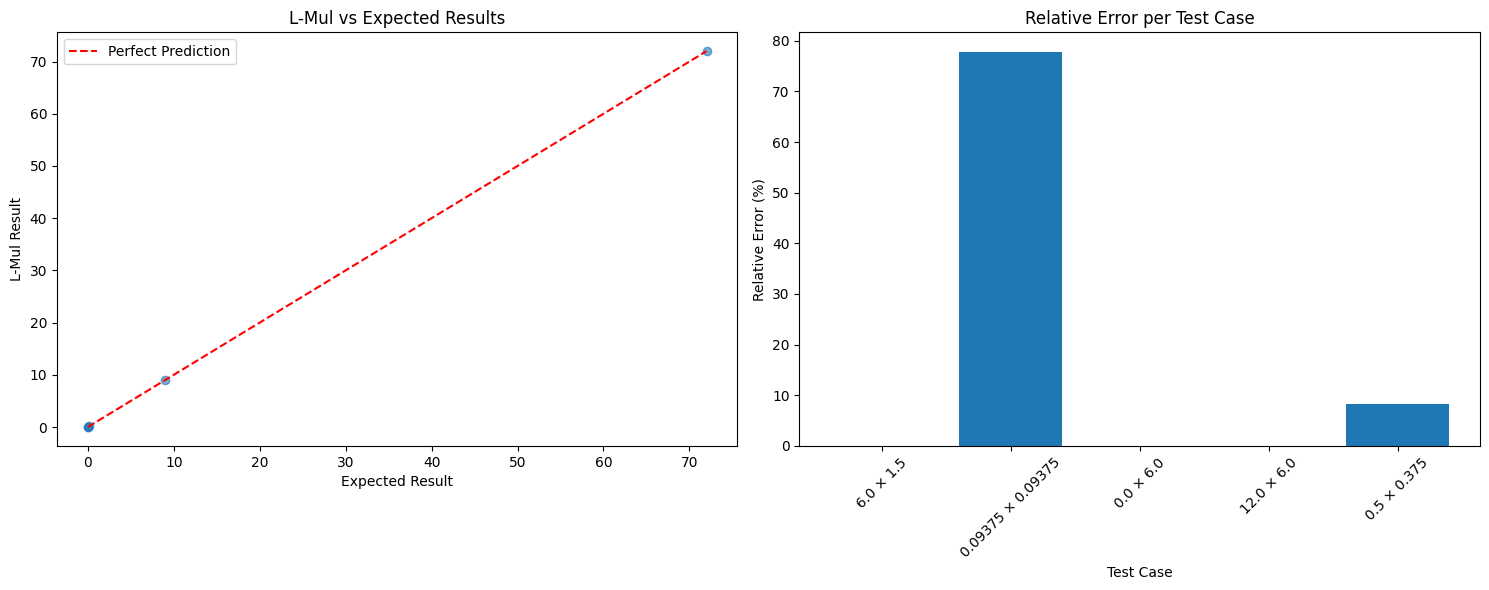

In [223]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_lmul_accuracy(df):
    # Create figure with multiple subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Scatter plot of expected vs actual results
    # This helps visualize how well the multiplier tracks the true values
    ax1.scatter(df['expected_decimal'], df['result_decimal'], alpha=0.6)
    
    # Add perfect prediction line (y=x)
    max_val = max(df['expected_decimal'].max(), df['result_decimal'].max())
    min_val = min(df['expected_decimal'].min(), df['result_decimal'].min())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
    
    ax1.set_xlabel('Expected Result')
    ax1.set_ylabel('L-Mul Result')
    ax1.set_title('L-Mul vs Expected Results')
    ax1.legend()
    
    # 2. Relative error analysis
    relative_error = np.abs(df['result_decimal'] - df['expected_decimal']) / np.abs(df['expected_decimal'])
    relative_error = relative_error.replace([np.inf, -np.inf], np.nan)  # Handle division by zero
    
    ax2.bar(range(len(df)), relative_error * 100)
    ax2.set_xlabel('Test Case')
    ax2.set_ylabel('Relative Error (%)')
    ax2.set_title('Relative Error per Test Case')
    
    # Add test case labels
    ax2.set_xticks(range(len(df)))
    ax2.set_xticklabels([f"{x} × {y}" for x, y in zip(df['x_decimal'], df['y_decimal'])], 
                        rotation=45)
    
    plt.tight_layout()
    
    # Print summary statistics
    print("\nAccuracy Statistics:")
    print(f"Mean Relative Error: {relative_error.mean()*100:.4f}%")
    print(f"Max Relative Error: {relative_error.max()*100:.4f}%")
    print(f"Mean Absolute Error: {np.abs(df['result_decimal'] - df['expected_decimal']).mean():.4f}")
    
    return fig

# Generate more comprehensive test cases
def generate_test_cases():
    test_cases = []
    
    # Test various combinations including:
    # - Normal * Normal
    # - Normal * Subnormal
    # - Powers of 2
    # - Numbers close to max/min
    # - Zero cases
    
    values = [
        0b00000000,  # 0
        0b00000100,  # Smallest subnormal
        0b00001100,  # Small normal
        0b00011100,  # 0.5
        0b00111100,  # 1.5
        0b01001100,  # 6.0
        0b01010100,  # 8.0
        0b01111110,  # Close to max
    ]
    
    # Generate all combinations
    for x in values:
        for y in values:
            test_cases.append((x, y))
            
    return test_cases

# Run with expanded test cases
df = test_lmul()
fig = analyze_lmul_accuracy(df)
plt.show()


Dataset Summary:
Total number of combinations: 64516

Error Statistics:
Mean Absolute Error: 1.6863
Mean Relative Error: 23.9230%
Max Absolute Error: 32.0000
Max Relative Error: 400.0000%

Accuracy Statistics:
Mean Relative Error: 23.9230%
Max Relative Error: 400.0000%
Mean Absolute Error: 1.6863


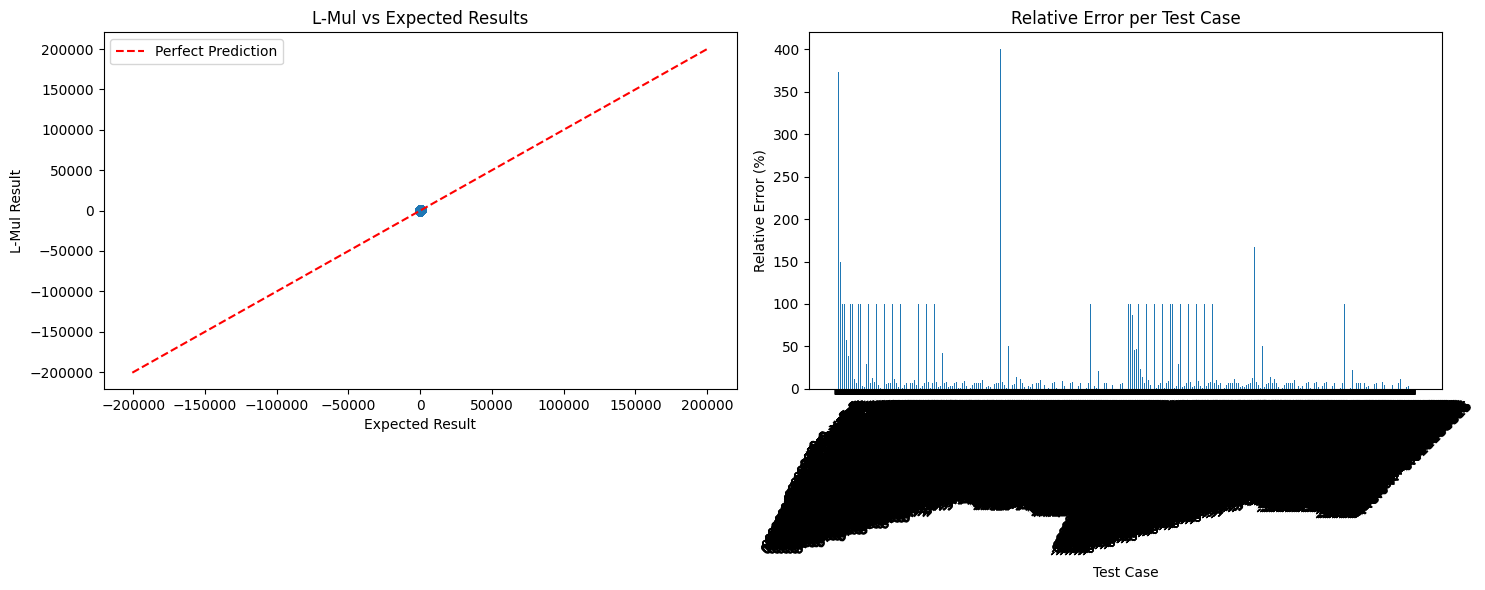

In [238]:
import pandas as pd
import numpy as np
from itertools import product

def generate_all_combinations():
    # For e4m3, valid values are 0-255 except those reserved for NaN
    # NaN in e4m3 is S.1111.111 (0b11111111 and 0b01111111)
    
    results = []
    # Generate all possible 8-bit numbers (0-255)
    all_numbers = list(range(256))
    # Remove NaN values
    valid_numbers = [x for x in all_numbers if x != 0b11111111 and x != 0b01111111]
    
    # Generate all possible combinations
    for x_bin, y_bin in product(valid_numbers, valid_numbers):
        # Convert inputs to decimal
        x_dec = fp8_e4m3_to_decimal(x_bin)
        y_dec = fp8_e4m3_to_decimal(y_bin)
        
        # Skip if either number is NaN
        if np.isnan(x_dec) or np.isnan(y_dec):
            continue
            
        # Calculate result using L-mul
        result_bin = float8_lmul(x_bin, y_bin)
        result_dec = fp8_e4m3_to_decimal(result_bin)
        
        # Calculate expected result
        expected_dec = x_dec * y_dec
        
        results.append({
            'x_binary': f'{x_bin:08b}',
            'x_decimal': x_dec,
            'y_binary': f'{y_bin:08b}',
            'y_decimal': y_dec,
            'result_binary': f'{result_bin:08b}',
            'result_decimal': result_dec,
            'expected_decimal': expected_dec
        })
    
    df = pd.DataFrame(results)
    
    # Add error metrics
    df['absolute_error'] = np.abs(df['result_decimal'] - df['expected_decimal'])
    df['relative_error'] = df['absolute_error'] / np.abs(df['expected_decimal'])
    # Handle division by zero in relative error
    df['relative_error'] = df['relative_error'].replace([np.inf, -np.inf], np.nan)
    
    return df

# Generate full dataset
df_full = generate_all_combinations()

# Print summary statistics
print("Dataset Summary:")
print(f"Total number of combinations: {len(df_full)}")
print("\nError Statistics:")
print(f"Mean Absolute Error: {df_full['absolute_error'].mean():.4f}")
print(f"Mean Relative Error: {df_full['relative_error'].mean()*100:.4f}%")
print(f"Max Absolute Error: {df_full['absolute_error'].max():.4f}")
print(f"Max Relative Error: {df_full['relative_error'].max()*100:.4f}%")

# Save to CSV for further analysis if needed
df_full.to_csv('lmul_full_analysis.csv', index=False)

# Generate visualization
fig = analyze_lmul_accuracy(df_full)
plt.show()


In [237]:
for i in range((2**8)**2):
    x = 100**2

256